In [70]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [71]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.25 13:12:35.630] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.25 13:12:35.633] INFO    VERSION: laboneq 2.51.0
[2025.08.25 13:12:35.635] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.25 13:12:35.638] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.25 13:12:35.644] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.25 13:12:35.650] INFO    Configuring the device setup
[2025.08.25 13:12:35.693] INFO    The device setup is configured


In [ ]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.2e9
qb_freq = 3.10268e9 #Q1
#qb_freq = 3.19586e9 #Q2
#qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

res_freq = 7.14885e9 #Q1
#res_freq = 7.18127e9 #Q2
#res_freq = 7.20642e9 #Q3
# res_freq = 7.23025e9 #Q4
# res_freq = 7.26202e9 #Q5
# res_freq = 7.29047e9 #Q6
rlx_time = 200e-6
integration_time = 5e-6
delay_start = 1e-8
delay_stop = 40e-6
delay_num = 101

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6

drive_pulse_amp = 0.330 #Q1
# drive_pulse_amp = 0.137 #Q2
# drive_pulse_amp = 0.072 #Q3
# drive_pulse_amp = 0.036 #Q4
#drive_pulse_amp = 0.028 #Q5
# drive_pulse_amp = 0.022 #Q6

drive_pulse_length = 4.83e-6 # Q1
# drive_pulse_length = e-6 # Q2
# drive_pulse_length = 5.326e-6 # Q3
# drive_pulse_length = 5.983e-6 # Q4
# drive_pulse_length = 5.983e-6 # Q5
# drive_pulse_length = 5.844e-6 # Q6

drive_range = 0
num_averages = 8  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9

In [92]:
#  signal map for qubit
def signal_map_default():
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

In [103]:
## define pulses
# qubit drive pulse - use amplitude calibrated by amplitude Rabi experiment
x180 = pulse_library.const(uid="x180", length=drive_pulse_length, amplitude=drive_pulse_amp)
# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=ro_pulse_length, amplitude=ro_pulse_amp)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=ro_pulse_amp
)

In [ ]:
delay_sweep = LinearSweepParameter(uid="delay", start=delay_start, stop=delay_stop, count=delay_num)

# number of averages
average_exponent = 4  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp = Experiment(
    uid="T1 experiment",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.SPECTROSCOPY,
    repetition_mode=RepetitionMode.AUTO,  # compiler sets repetition time to shortest possible constant time
):
    # inner loop - sweep over delay between qubit excitation and readout pulse
    # right alignment makes sure the readout section follows a fixed timing, being the last element in each shot
    with exp.sweep(
        uid="sweep", parameter=delay_sweep
    ):
        # qubit drive pulse followed by variable delay
        with exp.section(uid="qubit_excitation"):
            exp.play(signal="drive", pulse=x180)
            exp.delay(signal="drive", time=delay_sweep)
        # qubit readout pulse and data acquisition
        with exp.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            # exp.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            # exp.acquire(
            #     signal="acquire",
            #     handle="ac_0",
            #     kernel=readout_weighting_function,
            # )
            exp.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="T1",
                    reset_delay = 1e-6,
                )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp.section(uid="relax", length=rlx_time):
            exp.reserve(signal="measure")
            exp.reserve(signal = 'acquire')

In [105]:
# map exp to qubit 0
exp.set_signal_map(signal_map_default())


In [106]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp.set_calibration(exp_calibration)

In [107]:
# compile the experiment on the open instrument session
compiled_t1 = session.compile(exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/T1", compiled_t1)

[2025.08.25 13:17:05.768] INFO    Starting LabOne Q Compiler run...
[2025.08.25 13:17:05.807] INFO    Schedule completed. [0.035 s]
[2025.08.25 13:17:05.950] INFO    Code generation completed for all AWGs. [0.142 s]
[2025.08.25 13:17:05.952] INFO    Completed compilation step 1 of 1. [0.179 s]
[2025.08.25 13:17:05.958] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:17:05.959] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.25 13:17:05.960] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:17:05.961] INFO      device_shfqc        0        409            0           1     20000  
[2025.08.25 13:17:05.962] INFO      device_shfqc_sg     1         13            2           1     19328  
[2025.08.25 13:17:05.963] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:17:05.963] INFO      TOTAL                        422 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\T1_2025-08-25-13-17-05.html

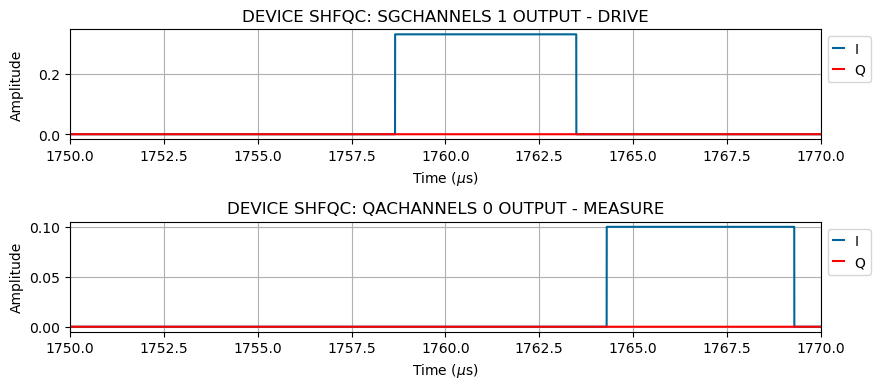

[2025.08.25 13:46:09.206] INFO    Starting LabOne Q Compiler run...
[2025.08.25 13:46:09.230] INFO    Schedule completed. [0.022 s]
[2025.08.25 13:46:09.292] INFO    Code generation completed for all AWGs. [0.061 s]
[2025.08.25 13:46:09.293] INFO    Completed compilation step 1 of 1. [0.085 s]
[2025.08.25 13:46:09.298] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:46:09.299] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.25 13:46:09.300] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:46:09.301] INFO      device_shfqc        0        409            0           1     20000  
[2025.08.25 13:46:09.301] INFO      device_shfqc_sg     1         13            2           1     19328  
[2025.08.25 13:46:09.302] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 13:46:09.303] INFO      TOTAL                        422 

In [111]:
plot_simulation(session.compiled_experiment, start_time=1750e-6, length=20e-6)
# run on qubit 0
my_results = session.run(exp)

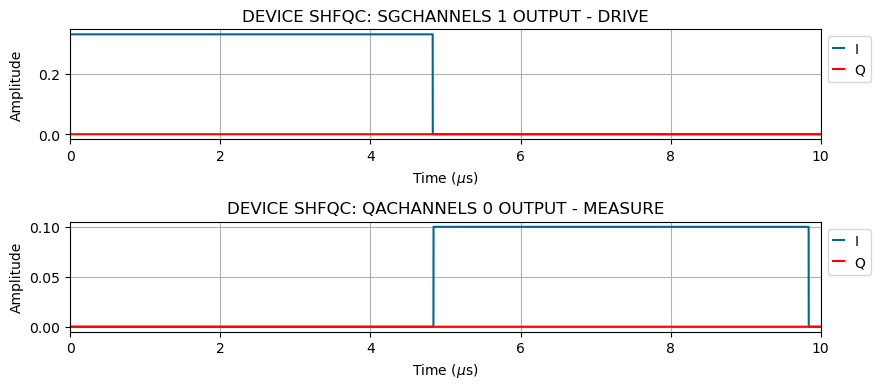

In [109]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)

In [110]:
# plot measurement results
plot_result_2d(my_results, "ac_0")

NameError: name 'plot_result_2d' is not defined

In [ ]:
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("T1", session.compiled_experiment)

In [ ]:
# map exp to qubit 1
exp.set_signal_map(map_qubit(q1))

# run on qubit 1
my_results = session.run(exp)